In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications import InceptionV3


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Dense, GlobalAveragePooling2D


from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score, classification_report

In [ ]:
(train_cat_dog, test_cat_dog) = tfds.load('cats_vs_dogs',
                                split=['train[:70%]', 'train[70%:]'],
                                shuffle_files=True,
                                as_supervised=True)
train_cat_dog = train_cat_dog.take(1227)
test_cat_dog = test_cat_dog.take(256)

In [ ]:
(train_horse_human, test_horse_human) = tfds.load('horses_or_humans',
                                split=['train', 'test'],
                                shuffle_files=True,
                                as_supervised=True)

In [ ]:
def preprocess_for_inc(image, label):
    image = tf.image.resize(image, (150, 150))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [ ]:
train_horse_human = train_horse_human.map(
        lambda x, y: preprocess_for_inc(x, y)
    )
test_horse_human = test_horse_human.map(
        lambda x, y: preprocess_for_inc(x, y)
    )

train_cat_dog = train_cat_dog.map(
        lambda x, y: preprocess_for_inc(x, y)
    )
test_cat_dog = test_cat_dog.map(
        lambda x, y: preprocess_for_inc(x, y)
    )

In [ ]:
val_horse_human = train_horse_human.take(200)
val_cat_dog = train_cat_dog.take(200)

train_horse_human = train_horse_human.skip(200)
train_cat_dog = train_cat_dog.skip(200)

In [ ]:
train_horse_human = train_horse_human.batch(32).prefetch(tf.data.AUTOTUNE)
test_horse_human = test_horse_human.batch(32).prefetch(tf.data.AUTOTUNE)
val_horse_human = val_horse_human.batch(32).prefetch(tf.data.AUTOTUNE)

train_cat_dog = train_cat_dog.batch(32).prefetch(tf.data.AUTOTUNE)
test_cat_dog = test_cat_dog.batch(32).prefetch(tf.data.AUTOTUNE)
val_cat_dog = val_cat_dog.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
model_inc = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3))
model_inc.trainable = False

model = Sequential([
        model_inc,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='sigmoid')
    ])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )


In [ ]:
history = model.fit(
    train_horse_human,
    epochs=10,
    validation_data=val_horse_human
)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 32s 767ms/step - accuracy: 0.8196 - loss: 0.9994 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - accuracy: 0.9938 - loss: 0.0337 - val_accuracy: 1.0000 - val_loss: 3.3807e-04
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step - accuracy: 0.9971 - loss: 0.0105 - val_accuracy: 1.0000 - val_loss: 9.4851e-05
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 1.0000 - loss: 3.1698e-04 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 1.0000 - loss: 4.9516e-04 - val_accuracy: 1.0000 - val_loss: 1.7080e-04
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 1.0000 - loss: 5.3739e-04 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 1.0000 - loss: 2.5058e-05 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 247ms/step - accuracy: 1.0000 - lo

In [ ]:
model_inc1 = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3))
model_inc1.trainable = False

model1 = Sequential([
        model_inc1,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='sigmoid')
    ])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

In [ ]:
history1 = model1.fit(
    train_cat_dog,
    epochs=10,
    validation_data=val_cat_dog
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 32s 590ms/step - accuracy: 0.7882 - loss: 1.1673 - val_accuracy: 0.9700 - val_loss: 0.0651
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9623 - loss: 0.1570 - val_accuracy: 0.9650 - val_loss: 0.0838
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9659 - loss: 0.1184 - val_accuracy: 0.9550 - val_loss: 0.1030
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9708 - loss: 0.0650 - val_accuracy: 0.9100 - val_loss: 0.2566
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9769 - loss: 0.0840 - val_accuracy: 0.9400 - val_loss: 0.1198
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9892 - loss: 0.0278 - val_accuracy: 0.9700 - val_loss: 0.0891
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.9933 - loss: 0.0219 - val_accuracy: 0.9600 - val_loss: 0.1164
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9951 - loss: 0.0148 - val_accuracy: 0.9550 -

In [ ]:
def ev_model(model, test_data):
    y_true = []
    y_pred_proba = []

    for images, labels in test_data:
        y_true.extend(labels.numpy())
        pred = model.predict(images, verbose=0)
        y_pred_proba.extend(pred)

    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)

    y_pred = np.argmax(y_pred_proba, axis=1)
    y_score = y_pred_proba[:, 1]


    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')


    plt.subplot(1, 3, 2)
    report = classification_report(y_true, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='Blues')
    plt.title('Classification Report')


    plt.subplot(1, 3, 3)
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    average_precision = average_precision_score(y_true, y_score)

    plt.plot(recall, precision, color='darkorange', lw=2,
             label=f'PR-кривая (AP = {average_precision:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall кривая')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_training_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

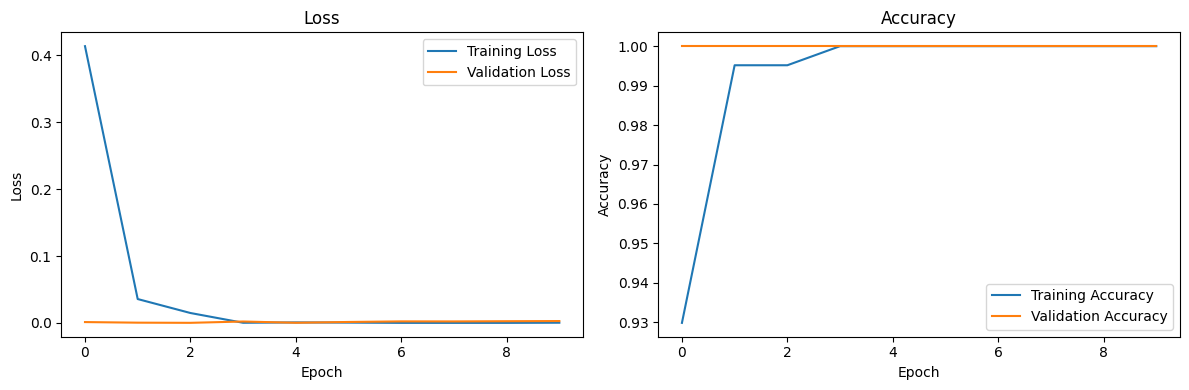

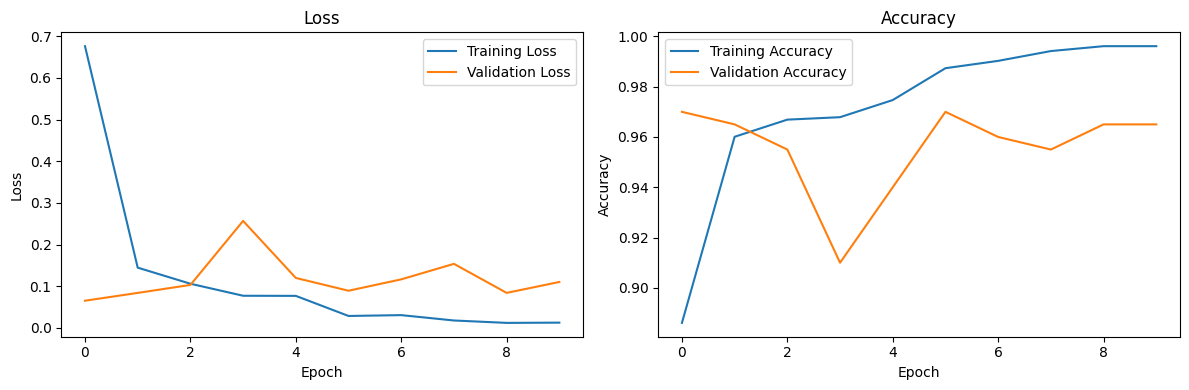

In [ ]:
plot_training_history(history)
plot_training_history(history1)

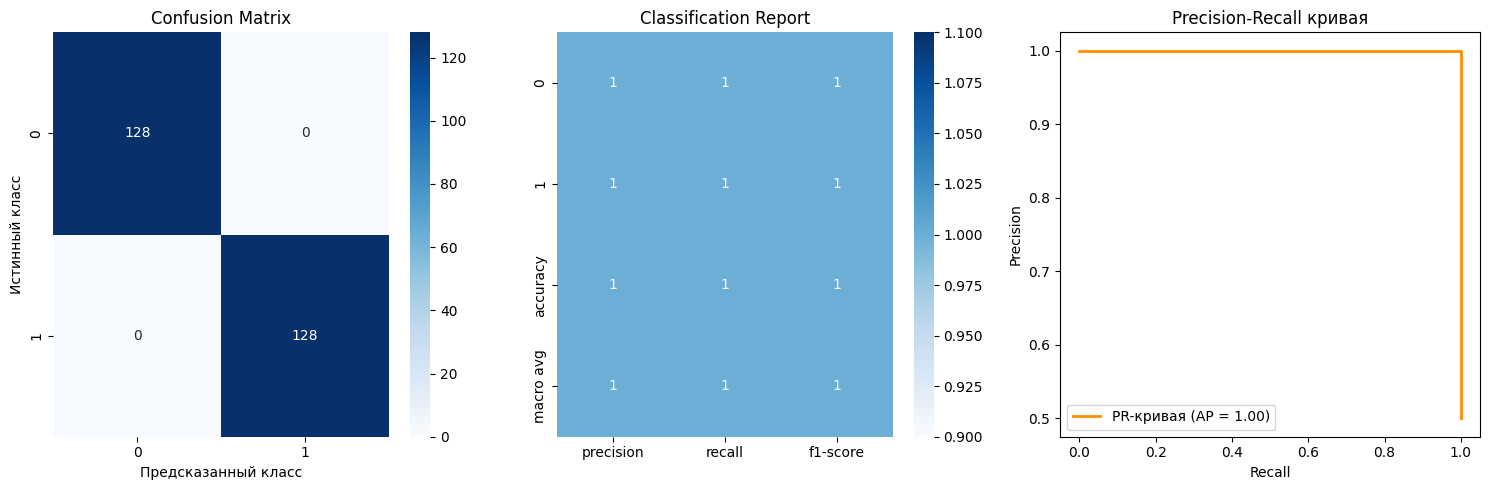

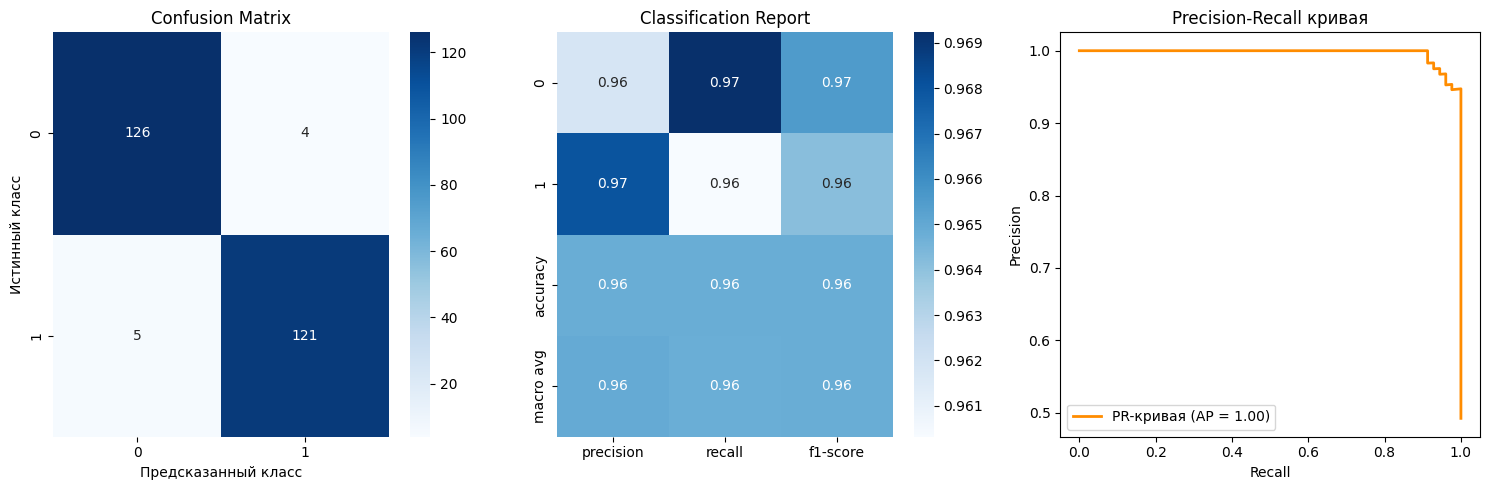

In [ ]:
ev_model(model, test_horse_human)
ev_model(model1, test_cat_dog)

Обе модели показывают хороший результат за исключением Horses vs Humans, тут имеется явное переобучение, как у Cats vs Dogs показывает хороший результат. Для улучшения можно упросить модель для HvH. На обоих графиках показывается хороший результат PR кривой.